# Solución del laboratorio 5: Intel: coordinar producción e inventario
**Profesor de laboratorio: Manuel López.** Material docente.
Los resultados guardados corresponden a la ejecución del mismo código en Python. Abra el notebook desde esta carpeta para conservar las rutas relativas.
El desarrollo matemático, la interpretación y la pauta de corrección están en el archivo .tex asociado.


plan_base
 periodo  demanda  regular  extra  inventario
       1     80.0    100.0    0.0        20.0
       2    120.0    100.0    0.0         0.0
       3    100.0    100.0    0.0         0.0

plan_sensibilidad
 periodo  demanda  regular  extra  inventario
       1     80.0     80.0    0.0         0.0
       2    120.0    100.0   20.0         0.0
       3    100.0    100.0    0.0         0.0

comparacion
   escenario  optimo  anticipacion  persecucion
        base  3040.0        3040.0       3120.0
sensibilidad  3040.0        3100.0       3040.0


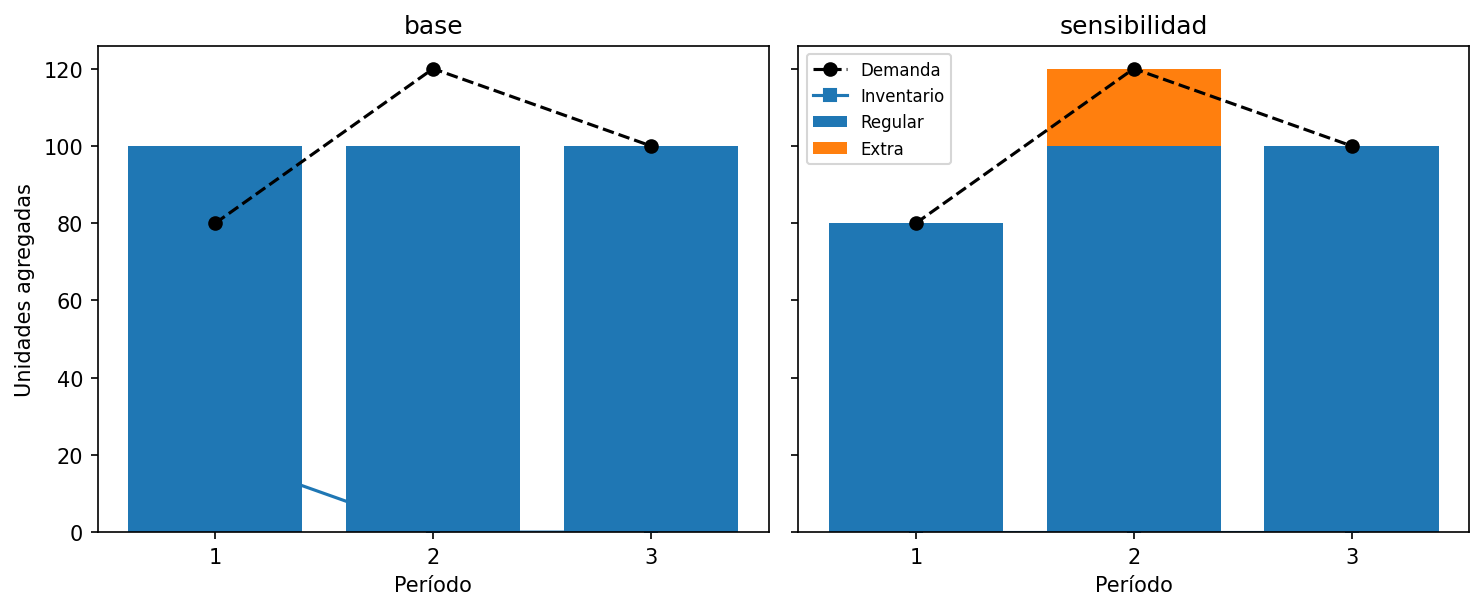

In [1]:
"""Solución docente de Gestión de Operaciones. Profesor: Manuel López."""
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
datos = base / "datos"
salida = base / "resultados"
salida.mkdir(exist_ok=True)
parametros = json.loads((datos / "parametros.json").read_text(encoding="utf-8"))

def tabla(df, nombre):
    df.to_csv(salida / (nombre + ".csv"), index=False)
    visible = df if len(df) <= 28 else df.head(12)
    print("\n" + nombre + "\n" + visible.to_string(index=False))
    if len(df) > 28:
        print(f"Vista inicial: {len(df)} filas completas en {nombre}.csv")

def figura(fig, nombre):
    fig.tight_layout()
    fig.savefig(salida / (nombre + ".png"), dpi=150, bbox_inches="tight")
    if "__file__" not in globals():
        plt.show()
    plt.close(fig)

def resumen(obj):
    def convertir(x):
        if isinstance(x, np.ndarray):
            return x.tolist()
        if isinstance(x, np.generic):
            return x.item()
        raise TypeError(type(x))
    (salida / "resumen.json").write_text(
        json.dumps(obj, ensure_ascii=False, indent=2, default=convertir),
        encoding="utf-8")

from scipy.optimize import linprog
periodos=pd.read_csv(datos / "periodos.csv")
costos=pd.read_csv(datos / "costos_escenarios.csv")
D=periodos.demanda_unidades.to_numpy(float)
K=periodos.capacidad_regular.to_numpy(float)
E=periodos.capacidad_extra.to_numpy(float)
n=len(D); tol=parametros["tolerancia"]
A=np.zeros((n,3*n)); b=D.copy(); b[0]-=parametros["inventario_inicial"]
for t in range(n):
    A[t,t]=1; A[t,n+t]=1; A[t,2*n+t]=-1
    if t>0:
        A[t,2*n+t-1]=1
bounds=[(0,k) for k in K]+[(0,e) for e in E]+[(0,None)]*n
bounds[-1]=(parametros["inventario_final"],parametros["inventario_final"])
referencias={"anticipacion":np.array([100,100,100,0,0,0,20,0,0]),
             "persecucion":np.array([80,100,100,0,20,0,0,0,0])}
registros=[]; soluciones={}
fig,axes=plt.subplots(1,2,figsize=(10,4.2),sharey=True)
for ax,row in zip(axes,costos.itertuples()):
    c=np.r_[np.repeat(row.costo_regular,n),np.repeat(row.costo_extra,n),
             np.repeat(row.costo_inventario,n)]
    r=linprog(c,A_eq=A,b_eq=b,bounds=bounds,method="highs")
    if not r.success:
        raise RuntimeError(f"{row.escenario}: {r.message}")
    R,O,I=np.split(r.x,3)
    assert np.max(np.abs(A@r.x-b))<=tol
    assert np.all(R>=-tol) and np.all(R<=K+tol)
    assert np.all(O>=-tol) and np.all(O<=E+tol) and np.all(I>=-tol)
    assert abs(I[-1]-parametros["inventario_final"])<=tol
    tabla(pd.DataFrame({"periodo":periodos.periodo,"demanda":D,"regular":R,
                        "extra":O,"inventario":I}),"plan_"+row.escenario)
    registro={"escenario":row.escenario,"optimo":r.fun}
    for nombre,x in referencias.items():
        assert np.allclose(A@x,b)
        registro[nombre]=float(c@x)
    registros.append(registro)
    soluciones[row.escenario]={"R":R,"O":O,"I":I,"costo":r.fun}
    ax.bar(periodos.periodo,R,label="Regular")
    ax.bar(periodos.periodo,O,bottom=R,label="Extra")
    ax.plot(periodos.periodo,D,"ko--",label="Demanda")
    ax.plot(periodos.periodo,I,"s-",label="Inventario")
    ax.set(title=row.escenario,xlabel="Período",xticks=periodos.periodo)
axes[0].set_ylabel("Unidades agregadas"); axes[1].legend(fontsize=8)
figura(fig,"planes"); tabla(pd.DataFrame(registros),"comparacion")
assert np.isclose(soluciones["base"]["costo"],3040)
assert np.isclose(soluciones["sensibilidad"]["costo"],3040)
resumen({"planes":soluciones,"comparacion":registros,"A_eq":A,"b_eq":b})
